<a href="https://www.kaggle.com/code/riteshkumarweb/polynomia-feature-in-logistic-regression?scriptVersionId=314992381" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [108]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vipullrathod/fish-market/Fish.csv


In [ ]:
# 📊 Polynomial Logistic Regression

# It means:
# Logistic Regression + Polynomial Features

# Used when data cannot be separated
# using a straight line

# Normal Logistic Regression
# → Creates a straight decision boundary

# Polynomial Logistic Regression
# → Creates a curved decision boundary 📈

# We add Polynomial Features like:
# x, x², x³, xy, etc.

# Example:
# Original feature:
# X = [x]

# After degree = 2:
# X = [x, x²]

# This helps the model learn complex patterns

# 🎯 Used when relationship is non-linear
# but the problem is still Classification

In [109]:
df = pd.read_csv('/kaggle/input/datasets/vipullrathod/fish-market/Fish.csv')

In [110]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [111]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

In [112]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,0,290.0,24.0,26.3,31.2,12.4800,4.3056
2,0,340.0,23.9,26.5,31.1,12.3778,4.6961
3,0,363.0,26.3,29.0,33.5,12.7300,4.4555
4,0,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,5,12.2,11.5,12.2,13.4,2.0904,1.3936
155,5,13.4,11.7,12.4,13.5,2.4300,1.2690
156,5,12.2,12.1,13.0,13.8,2.2770,1.2558
157,5,19.7,13.2,14.3,15.2,2.8728,2.0672


In [113]:
df.sample(10)

,Species,Weight,Length1,Length2,Length3,Height,Width
63,1,90.0,16.3,17.7,19.8,7.4052,2.6730
111,2,840.0,32.5,35.0,37.3,11.4884,7.7957
88,2,130.0,20.0,22.0,23.5,6.1100,3.5250
129,3,300.0,31.7,34.0,37.8,5.7078,4.1580
92,2,150.0,20.5,22.5,24.0,6.7920,3.6240
131,3,300.0,34.8,37.3,39.8,6.2884,4.0198
62,1,60.0,14.3,15.5,17.4,6.5772,2.3142
14,0,600.0,29.4,32.0,37.2,14.9544,5.1708
20,0,575.0,31.3,34.0,39.5,15.1285,5.5695
97,2,145.0,22.0,24.0,25.5,6.3750,3.8250


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    int64  
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 8.8 KB


In [115]:
df.corr()

,Species,Weight,Length1,Length2,Length3,Height,Width
Species,1.000000,-0.312960,-0.266696,-0.283601,-0.335519,-0.698193,-0.397578
Weight,-0.312960,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,-0.266696,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,-0.283601,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,-0.335519,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,-0.698193,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,-0.397578,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


In [116]:
df.corr()['Species'].sort_values()

Height    -0.698193
Width     -0.397578
Length3   -0.335519
Weight    -0.312960
Length2   -0.283601
Length1   -0.266696
Species    1.000000
Name: Species, dtype: float64

In [117]:
df.groupby("Species").mean()

,Weight,Length1,Length2,Length3,Height,Width
Species,,,,,,
0,617.828571,30.305714,33.108571,38.354286,15.183211,5.427614
1,154.818182,18.727273,20.345455,22.790909,8.962427,3.220736
2,382.239286,25.735714,27.892857,29.571429,7.861870,4.745723
3,718.705882,42.476471,45.482353,48.717647,7.713771,5.086382
4,152.050000,20.645000,22.275000,24.970000,6.694795,3.657850
5,11.178571,11.257143,11.921429,13.035714,2.209371,1.340093
6,531.000000,28.800000,31.316667,34.316667,10.027167,5.473050


In [118]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

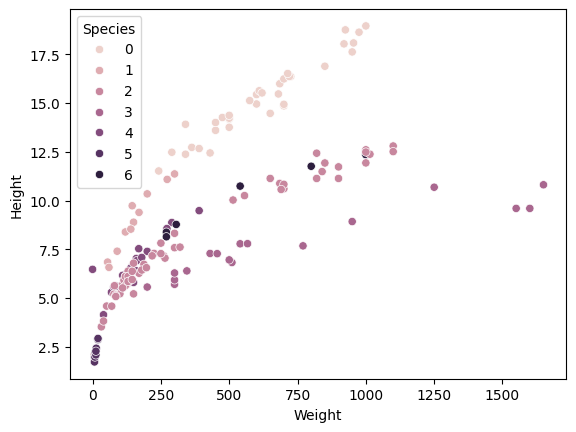

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x="Weight", y="Height", hue="Species")
plt.show()

In [120]:
df.drop(columns=['Length1', 'Length2', 'Length3'],inplace = True)

In [121]:
df

,Species,Weight,Height,Width
0,0,242.0,11.5200,4.0200
1,0,290.0,12.4800,4.3056
2,0,340.0,12.3778,4.6961
3,0,363.0,12.7300,4.4555
4,0,430.0,12.4440,5.1340
...,...,...,...,...
154,5,12.2,2.0904,1.3936
155,5,13.4,2.4300,1.2690
156,5,12.2,2.2770,1.2558
157,5,19.7,2.8728,2.0672


In [122]:
X = df.iloc[:,1:4]
X

,Weight,Height,Width
0,242.0,11.5200,4.0200
1,290.0,12.4800,4.3056
2,340.0,12.3778,4.6961
3,363.0,12.7300,4.4555
4,430.0,12.4440,5.1340
...,...,...,...
154,12.2,2.0904,1.3936
155,13.4,2.4300,1.2690
156,12.2,2.2770,1.2558
157,19.7,2.8728,2.0672


In [123]:
y = df.iloc[:,0]
y

0      0
1      0
2      0
3      0
4      0
      ..
154    5
155    5
156    5
157    5
158    5
Name: Species, Length: 159, dtype: int64

In [124]:
from sklearn.model_selection import train_test_split
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [125]:
X_train

,Weight,Height,Width
75,51.5,4.5924,2.6316
138,567.0,7.7920,4.8700
2,340.0,12.3778,4.6961
86,120.0,6.1100,3.4075
45,160.0,7.0334,3.8203
...,...,...,...
71,300.0,11.3680,4.2340
106,250.0,7.8204,4.2042
14,600.0,14.9544,5.1708
92,150.0,6.7920,3.6240


In [126]:
y_train


75     2
138    3
2      0
86     2
45     4
      ..
71     1
106    2
14     0
92     2
102    2
Name: Species, Length: 127, dtype: int64

In [127]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [128]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [129]:
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [130]:
y_pred = model.predict(X_test_scaled)

In [131]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test , y_pred)

0.8125

In [132]:
from sklearn.preprocessing import PolynomialFeatures

In [133]:
# Create Polynomial Features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Logistic Regression Model
model = LogisticRegression()

model.fit(X_train_poly, y_train)

# Prediction
y_prediction = model.predict(X_test_poly)

# Results
print("Accuracy:", accuracy_score(y_test, y_prediction))

Accuracy: 0.84375


In [134]:
score1= accuracy_score(y_test , y_pred)
score2= accuracy_score(y_test, y_prediction)

print(f'This is Accuracy of LogisticRegression {score1*100}% for this data ')
print(f'This is Accuracy of PolynominaLogisticRegression {score2*100}% for this data')

This is Accuracy of LogisticRegression 81.25% for this data 
This is Accuracy of PolynominaLogisticRegression 84.375% for this data
